In [1]:
import os
import sys

# 1. Zistenie cesty ku Conda knižniciam
conda_env_path = sys.prefix
bin_path = os.path.join(conda_env_path, 'Library', 'bin')

# 2. Klasické nastavenie PATH
os.environ['PATH'] = bin_path + os.pathsep + os.environ['PATH']

# 3. Silnejšia zbraň pre Windows a Python 3.8+ (Donúti načítať .dll súbory)
try:
    os.add_dll_directory(bin_path)
except AttributeError:
    pass 

# 4. Až TERAZ importujeme tensorflow
import tensorflow as tf

# 5. Skrotenie pamäte grafickej karty
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU je úspešne pripravené a pamäť je nastavená na:", len(gpus), "GPU")
    except RuntimeError as e:
        print(e)
else:
    print("❌ GPU sa nenašlo.")

✅ GPU je úspešne pripravené a pamäť je nastavená na: 1 GPU


In [2]:
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import numpy as np
import random

In [3]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
CHANNELS = 1

batch_size = 8

datagen = ImageDataGenerator(rescale=1./255)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 
)

train_generator = datagen.flow_from_directory(
    'casting_512x512/casting_512x512/',
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = batch_size,
    class_mode = 'input',
    color_mode = 'grayscale',
    classes=['ok_front'],
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    'casting_512x512/casting_512x512/',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=batch_size,
    class_mode='input',
    color_mode = 'grayscale',
    classes=['ok_front'],
    subset='validation'
    )

Found 416 images belonging to 1 classes.


Found 103 images belonging to 1 classes.


In [4]:
#Encoder
model = Sequential()
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))

#Decoder
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))

In [5]:
model.add(Conv2D(1, (3, 3), activation='sigmoid', padding='same'))

In [6]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 256, 256, 64)      640       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 128, 128, 64)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      18464     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 64, 64, 32)       0         
 2D)                                                             


                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 16)        4624      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 32, 32, 16)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 32, 32, 16)        2320      
                                                                 
 up_sampling2d (UpSampling2D  (None, 64, 64, 16)       0         
 )                                                               
                                                                 
 conv2d_4 (Conv2D)           (None, 64, 64, 32)        4640      
                                                                 
 up_sampling2d_1 (UpSampling  (None, 128, 128, 32)     0         
 2D)                                                             
          

In [7]:
history = model.fit(
        train_generator,
        epochs=5,
        validation_data=validation_generator,
        shuffle = True)

Epoch 1/5
52/52 [==============================] - 12s 115ms/step - loss: 0.0291 - mse: 0.0291 - val_loss: 0.0079 - val_mse: 0.0079
Epoch 2/5
52/52 [==============================] - 5s 98ms/step - loss: 0.0066 - mse: 0.0066 - val_loss: 0.0054 - val_mse: 0.0054
Epoch 3/5
52/52 [==============================] - 5s 97ms/step - loss: 0.0047 - mse: 0.0047 - val_loss: 0.0044 - val_mse: 0.0044
Epoch 4/5
52/52 [==============================] - 5s 95ms/step - loss: 0.0041 - mse: 0.0041 - val_loss: 0.0040 - val_mse: 0.0040
Epoch 5/5
52/52 [==============================] - 5s 95ms/step - loss: 0.0037 - mse: 0.0037 - val_loss: 0.0035 - val_mse: 0.0035


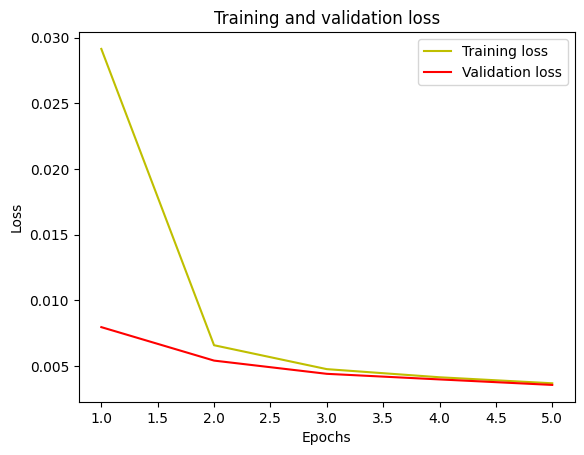

In [8]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()